# Scale-invariant transfer — test on all cities (3-way)

Applies three Barcelona models to every deployment city and compares:
- **raw-18** — the original deployed model, all 18 features raw (`notebooks/_elena/models/`).
- **SI-10** — only the 10 network features, percentile-ranked.
- **SI-18** — all 18 features, with the 10 network features percentile-ranked and the 8 local features raw.

**No geospatial recomputation:** each city's raw distance/centrality columns already exist in its dataset
CSV; we only `read_csv`, percentile-rank within the city, and predict.

## Libraries, models and the percentile transform

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

NETWORK_10 = [
    'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary',
    'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street',
    'betweenness', 'closeness_global', 'closeness_400', 'straightness',
]
def add_pct(df):
    out = df.copy()
    for f in NETWORK_10:
        out[f + '_pct'] = out[f].rank(pct=True)
    return out

In [2]:
SI = '../models'
RAW = '../../notebooks/_elena/models'

def load(p):
    with open(p, 'rb') as f:
        return pickle.load(f)

# ---- three variants: (scaler, feature_columns, {model_name: model}) for class and regre ----
def bundle(scaler_c, feats_c, class_files, scaler_r, feats_r, regre_files, base):
    return {
        'scaler_c': load(f'{base}/{scaler_c}'), 'feats_c': load(f'{base}/{feats_c}'),
        'class': {n: load(f'{base}/{fn}') for n, fn in class_files.items()},
        'scaler_r': load(f'{base}/{scaler_r}'), 'feats_r': load(f'{base}/{feats_r}'),
        'regre': {n: load(f'{base}/{fn}') for n, fn in regre_files.items()},
    }

CLS = {'Logistic Regression': 'logreg', 'XGBoost': 'xgb', 'Random Forest': 'rf'}
REG = {'Linear Regression': 'linreg', 'XGBoost': 'xgb', 'Random Forest': 'rf'}

variants = {
    'raw-18': bundle('Sscaler.pkl', 'feature_columns.pkl',
                     {n: f'{k}_class_model.pkl' for n, k in CLS.items()},
                     'Sscaler_regre.pkl', 'feature_columns_regre.pkl',
                     {n: f'{k}_regre_model.pkl' for n, k in REG.items()}, RAW),
    'SI-10':  bundle('Sscaler_si.pkl', 'feature_columns_si.pkl',
                     {n: f'{k}_class_si.pkl' for n, k in CLS.items()},
                     'Sscaler_si.pkl', 'feature_columns_si.pkl',
                     {n: f'{k}_regre_si.pkl' for n, k in REG.items()}, SI),
    'SI-18':  bundle('Sscaler_si18.pkl', 'feature_columns_si18.pkl',
                     {n: f'{k}_class_si18.pkl' for n, k in CLS.items()},
                     'Sscaler_si18.pkl', 'feature_columns_si18.pkl',
                     {n: f'{k}_regre_si18.pkl' for n, k in REG.items()}, SI),
}
print('variants:', list(variants))
for v, b in variants.items():
    print(f'  {v}: {len(b["feats_c"])} class feats, {len(b["feats_r"])} regre feats')

variants: ['raw-18', 'SI-10', 'SI-18']
  raw-18: 18 class feats, 18 regre feats
  SI-10: 10 class feats, 10 regre feats
  SI-18: 18 class feats, 18 regre feats


## City configuration

In [3]:
cities = [
    ('Viladecans', 'vil', 'VIL'),
    ('Milan',      'mil', 'MIL'),
    ('Berlin',     'ber', 'BER'),
    ('Lyon',       'lyo', 'LYO'),
    ('Zaragoza',   'zgz', 'ZGZ'),
]
RESULTS = '../results'
os.makedirs(RESULTS, exist_ok=True)

## Evaluate all three variants on every city (both tasks)

In [4]:
class_rows, regre_rows = [], []

for city, xxx, XXX in cities:
    dfc = add_pct(pd.read_csv(f'../../deployment/{city}/notebooks/data/{xxx}_noise_class_ml_dataset.csv'))
    dfr = add_pct(pd.read_csv(f'../../deployment/{city}/notebooks/data/{xxx}_noise_regre_ml_dataset.csv'))
    yc = dfc['noise_day'].to_numpy()
    yr = dfr['noise_day'].to_numpy(dtype=float)

    cls_pred = {'road_id': dfc['road_id'].values, 'noise_day_true': yc}
    reg_pred = {'road_id': dfr['road_id'].values, 'db_true': yr}

    for vname, b in variants.items():
        Xc = b['scaler_c'].transform(dfc[b['feats_c']])
        Xr = b['scaler_r'].transform(dfr[b['feats_r']])
        for m in ['Logistic Regression', 'XGBoost', 'Random Forest']:
            yp = b['class'][m].predict(Xc)
            class_rows.append({'city': city, 'model': m, 'variant': vname,
                               'accuracy': accuracy_score(yc, yp),
                               'macro_f1': f1_score(yc, yp, average='macro'),
                               'within_1': np.mean(np.abs(yp - yc) <= 1),
                               'signed_err': np.mean(yp - yc)})
        for m in ['Linear Regression', 'XGBoost', 'Random Forest']:
            yp = np.asarray(b['regre'][m].predict(Xr), dtype=float)
            regre_rows.append({'city': city, 'model': m, 'variant': vname,
                               'r2': r2_score(yr, yp), 'mae': mean_absolute_error(yr, yp),
                               'rmse': np.sqrt(mean_squared_error(yr, yp)),
                               'signed_err': np.mean(yp - yr)})
        if vname == 'SI-18':   # save the new hybrid model's predictions for maps
            cls_pred['pred_rf_si18'] = b['class']['Random Forest'].predict(Xc)
            yp_rf = np.asarray(b['regre']['Random Forest'].predict(Xr), dtype=float)
            reg_pred['pred_rf_si18'] = yp_rf.round(2)
            reg_pred['db_diff_rf_si18'] = (yp_rf - yr).round(2)

    pd.DataFrame(cls_pred).to_csv(f'{RESULTS}/{xxx.lower()}_si18_predictions_class.csv', index=False)
    pd.DataFrame(reg_pred).to_csv(f'{RESULTS}/{xxx.lower()}_si18_predictions_regre.csv', index=False)
    print('done:', city)

class_cmp = pd.DataFrame(class_rows); regre_cmp = pd.DataFrame(regre_rows)
class_cmp.to_csv(f'{RESULTS}/si_transfer_comparison_class.csv', index=False)
regre_cmp.to_csv(f'{RESULTS}/si_transfer_comparison_regre.csv', index=False)
print('saved 3-way comparison CSVs')

done: Viladecans


done: Milan


done: Berlin


done: Lyon


done: Zaragoza
saved 3-way comparison CSVs


### Classification accuracy — raw-18 vs SI-10 vs SI-18 (Random Forest)

In [5]:
order = [c[0] for c in cities]
(class_cmp[class_cmp.model == 'Random Forest']
 .pivot(index='city', columns='variant', values='accuracy')
 .reindex(order)[['raw-18', 'SI-10', 'SI-18']].round(3))

variant,raw-18,SI-10,SI-18
city,,,
Viladecans,0.469,0.469,0.490
Milan,0.690,0.734,0.737
Berlin,0.301,0.222,0.257
Lyon,0.533,0.490,0.524
Zaragoza,0.307,0.415,0.363


### Regression R² — raw-18 vs SI-10 vs SI-18 (Random Forest)

In [6]:
(regre_cmp[regre_cmp.model == 'Random Forest']
 .pivot(index='city', columns='variant', values='r2')
 .reindex(order)[['raw-18', 'SI-10', 'SI-18']].round(3))

variant,raw-18,SI-10,SI-18
city,,,
Viladecans,-0.521,0.290,0.279
Milan,-3.834,-3.129,-3.067
Berlin,0.111,-0.468,-0.219
Lyon,-0.560,-0.719,-0.388
Zaragoza,-0.557,0.017,-0.131


## Headline figure — raw vs scale-invariant transfer (Random Forest)

Left: classification accuracy (higher = better). Right: regression R² (higher = better; floored at −2 for
display, true values labelled). Three bars per city: raw-18, SI-10, SI-18.

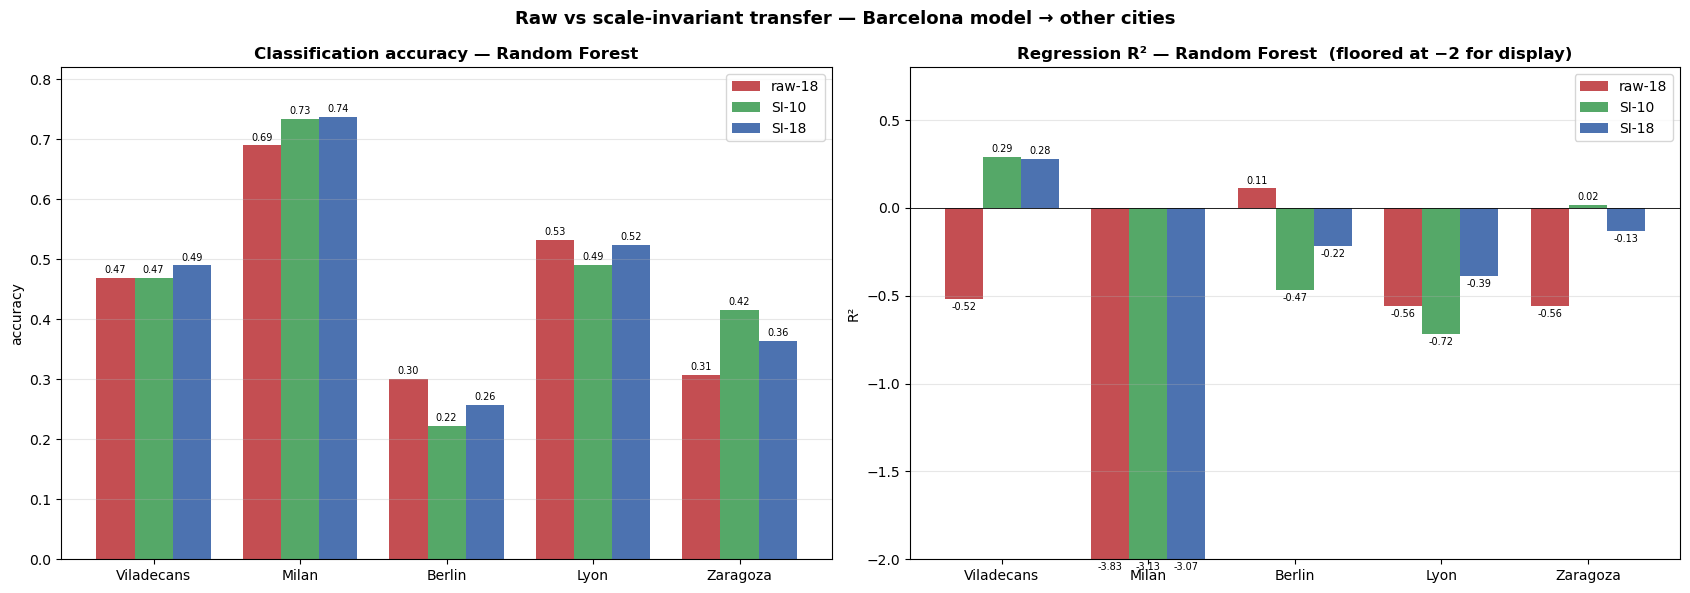

In [7]:
colors = {'raw-18': '#c44e52', 'SI-10': '#55a868', 'SI-18': '#4c72b0'}
vlist = ['raw-18', 'SI-10', 'SI-18']
x = np.arange(len(order)); w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sub = class_cmp[class_cmp.model == 'Random Forest']
for j, v in enumerate(vlist):
    vals = [sub[(sub.city == c) & (sub.variant == v)]['accuracy'].values[0] for c in order]
    b = axes[0].bar(x + (j - 1) * w, vals, w, label=v, color=colors[v])
    axes[0].bar_label(b, fmt='%.2f', fontsize=7, padding=2)
axes[0].set_xticks(x); axes[0].set_xticklabels(order)
axes[0].set_title('Classification accuracy — Random Forest', fontweight='bold')
axes[0].set_ylabel('accuracy'); axes[0].set_ylim(0, 0.82)
axes[0].grid(axis='y', alpha=0.3); axes[0].legend()

sub = regre_cmp[regre_cmp.model == 'Random Forest']; floor = -2.0
for j, v in enumerate(vlist):
    true = [sub[(sub.city == c) & (sub.variant == v)]['r2'].values[0] for c in order]
    b = axes[1].bar(x + (j - 1) * w, [max(t, floor) for t in true], w, label=v, color=colors[v])
    axes[1].bar_label(b, labels=[f'{t:.2f}' for t in true], fontsize=7, padding=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(order)
axes[1].set_title('Regression R² — Random Forest  (floored at −2 for display)', fontweight='bold')
axes[1].set_ylabel('R²'); axes[1].set_ylim(floor, 0.8)
axes[1].axhline(0, color='k', lw=0.6); axes[1].grid(axis='y', alpha=0.3); axes[1].legend()

fig.suptitle('Raw vs scale-invariant transfer — Barcelona model → other cities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS}/fig_si_vs_raw_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-city error maps — SI-18 regression (Random Forest)

`db_diff = predicted − real` dB for the hybrid SI-18 RF model. Saved to HTML per city.

In [8]:
for city, xxx, XXX in cities:
    preds = pd.read_csv(f'{RESULTS}/{xxx.lower()}_si18_predictions_regre.csv')
    roads = gpd.read_file(f'../../deployment/{city}/layers/{XXX}_noise_streets.gpkg')
    merged = roads.merge(preds, left_on='segment_id', right_on='road_id', how='left')
    m = merged.to_crs(epsg=4326).explore(
        column='db_diff_rf_si18', cmap='RdBu_r', vmin=-15, vmax=15,
        tiles='CartoDB positron',
        tooltip=['road_id', 'db_diff_rf_si18', 'pred_rf_si18', 'db_true', 'highway'],
        legend=True)
    out = f'{RESULTS}/{xxx.lower()}_si18_map_db_diff_rf.html'
    m.save(out)
    print('saved', out)

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


saved ../results/vil_si18_map_db_diff_rf.html


saved ../results/mil_si18_map_db_diff_rf.html


saved ../results/ber_si18_map_db_diff_rf.html


saved ../results/lyo_si18_map_db_diff_rf.html


saved ../results/zgz_si18_map_db_diff_rf.html
